In [1]:
from sklearn.cluster import DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram


from umap import UMAP

import pandas as pd
import numpy as np

from config import *
from pandas.api.types import CategoricalDtype
import scipy.sparse as sparse

import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d

from tqdm import tqdm

from functools import reduce

from utils import HourOfDayEncoder, DOWEncoder
orders = pd.read_parquet(ORDERS_PATH)
orders_products = pd.read_parquet(ORDER_PRODUCTS__TRAIN_PATH)
orders_orders_products = orders.merge(orders_products, how='inner',on = 'order_id')
products = pd.read_parquet(PRODUCTS_PATH)
departments = pd.read_parquet(DEPARTMENTS_PATH)
aisle = pd.read_parquet(AISLES_PATH)

order_all_info = (orders_orders_products
 .merge(products, how='inner', on='product_id')
 .merge(departments, how='inner', on ='department_id')
 .merge(aisle, how='inner', on ='aisle_id')
)

/Users/krusand/Documents/GitHub/02807-CT-Project/.venv/lib/python3.10/site-packages/llvmlite/binding/ffi.py:175: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename
/Users/krusand/Documents/GitHub/02807-CT-Project/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Features based on user features

The following features will be implemented: 

- Number of orders a user has made: _are they a shopper who orders a lot, or a shopper with fewer orders?_
- Avg number of products in baskets: _do they shop small baskets or large baskets? -> family or single_
- User frequency: _how often does the user shop?_
- Reorder frequency: Same product types?

Sebastian:
- Avg + var hour of day
- Avg + var dow

Possibly: 
- Frequency of department id -> which product types do they buy?



In [2]:
# Number of orders a user has made: _are they a shopper who orders a lot, or a shopper with fewer orders?_

n_orders = (orders
              .groupby(["user_id"])
              .size()
              .reset_index(name="n_orders_u"))

# Avg number of products in baskets: _do they shop small baskets or large baskets? -> family or single_
products_pr_order = (orders_orders_products
 .groupby(["user_id", "order_id"])
 ["product_id"]
 .size()
 .reset_index(name='n_products_pr_order')
 .groupby(["user_id"])
 ["n_products_pr_order"]
 .mean()
 .reset_index(name='avg_products_pr_order')
 )

# User frequency: _how often does the user shop?_

order_frequency = (orders
 .groupby(["user_id"])
 ["days_since_prior_order"]
 .mean()
 .reset_index(name='avg_days_since_prior_order')
 )

# Reorder frequency: Same product types?
reorders = (orders_orders_products
 .groupby(["user_id"])
 .agg(n_products = ('reordered', 'size'),
      n_reorders = ('reordered', 'sum')
      )
 .reset_index()
 .assign(frac_reorders = lambda x: x["n_reorders"]/x['n_products'])
 )

# Avg hour of day
hour_enc = HourOfDayEncoder(return_pd=True)
avg_order_of_hour = (hour_enc
          .fit_transform(orders)
          .groupby(["user_id"])
          .agg(avg_x_hour = ('X_hour_dir', 'mean'),
               avg_y_hour = ('Y_hour_dir', 'mean')
               )
          .reset_index()
          )


# Avg dow

dow_enc = DOWEncoder(return_pd=True)
avg_order_dow = (dow_enc
          .fit_transform(X=orders)
          .groupby(["user_id"])
          .agg(avg_x_dow = ('X_day_dir', 'mean'),
               avg_y_dow = ('Y_day_dir', 'mean')
               )
          .reset_index()
          )


# Fraction in departments:

products_pr_user = (orders_orders_products
 .groupby(["user_id"])
 ["product_id"] 
 .size()
 .reset_index(name="n_products_pr_user")
 )


products_pr_user_pr_department = (order_all_info
 .groupby(["user_id", "department_id"])
 .size()
 .reset_index(name='n_products')
 )

frac_department = (products_pr_user_pr_department
 .merge(products_pr_user, on ='user_id', how='inner')
 .assign(frac_products_in_department = lambda x: x['n_products'] / x["n_products_pr_user"])
 [["user_id", "department_id", "frac_products_in_department"]]
 .pivot(index='user_id', columns='department_id', values="frac_products_in_department")
 .fillna(0)
)
frac_department.columns = [f"dep_id_{i}" for i in frac_department.columns]
frac_department = frac_department.reset_index()


In [3]:
feature_dfs = [n_orders, products_pr_order, order_frequency, reorders, avg_order_dow, avg_order_of_hour, frac_department]

def get_feature_columns(feature_dfs: list[pd.DataFrame]) -> list:
    feature_cols = []
    for df in feature_dfs:
        df_column_set = set(df.columns.tolist())
        df_column_set.remove('user_id')
        for col in list(df_column_set):
            feature_cols.append(col)

    return feature_cols

feature_columns = get_feature_columns(feature_dfs)
# merge all feature dfs, and select all columns which are not 'user_id' in those dfs
X = (reduce(lambda x,y: pd.merge(x,y, on='user_id'), feature_dfs)[feature_columns])

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

X_sample = X_scaled.sample(50000)

print(f"Total features: {len(feature_columns)}")

Total features: 31


****
# Dimensionality reduction for plotting

## PCA
Looks like a big blob of data

/Users/krusand/Documents/GitHub/02807-CT-Project/.venv/lib/python3.10/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


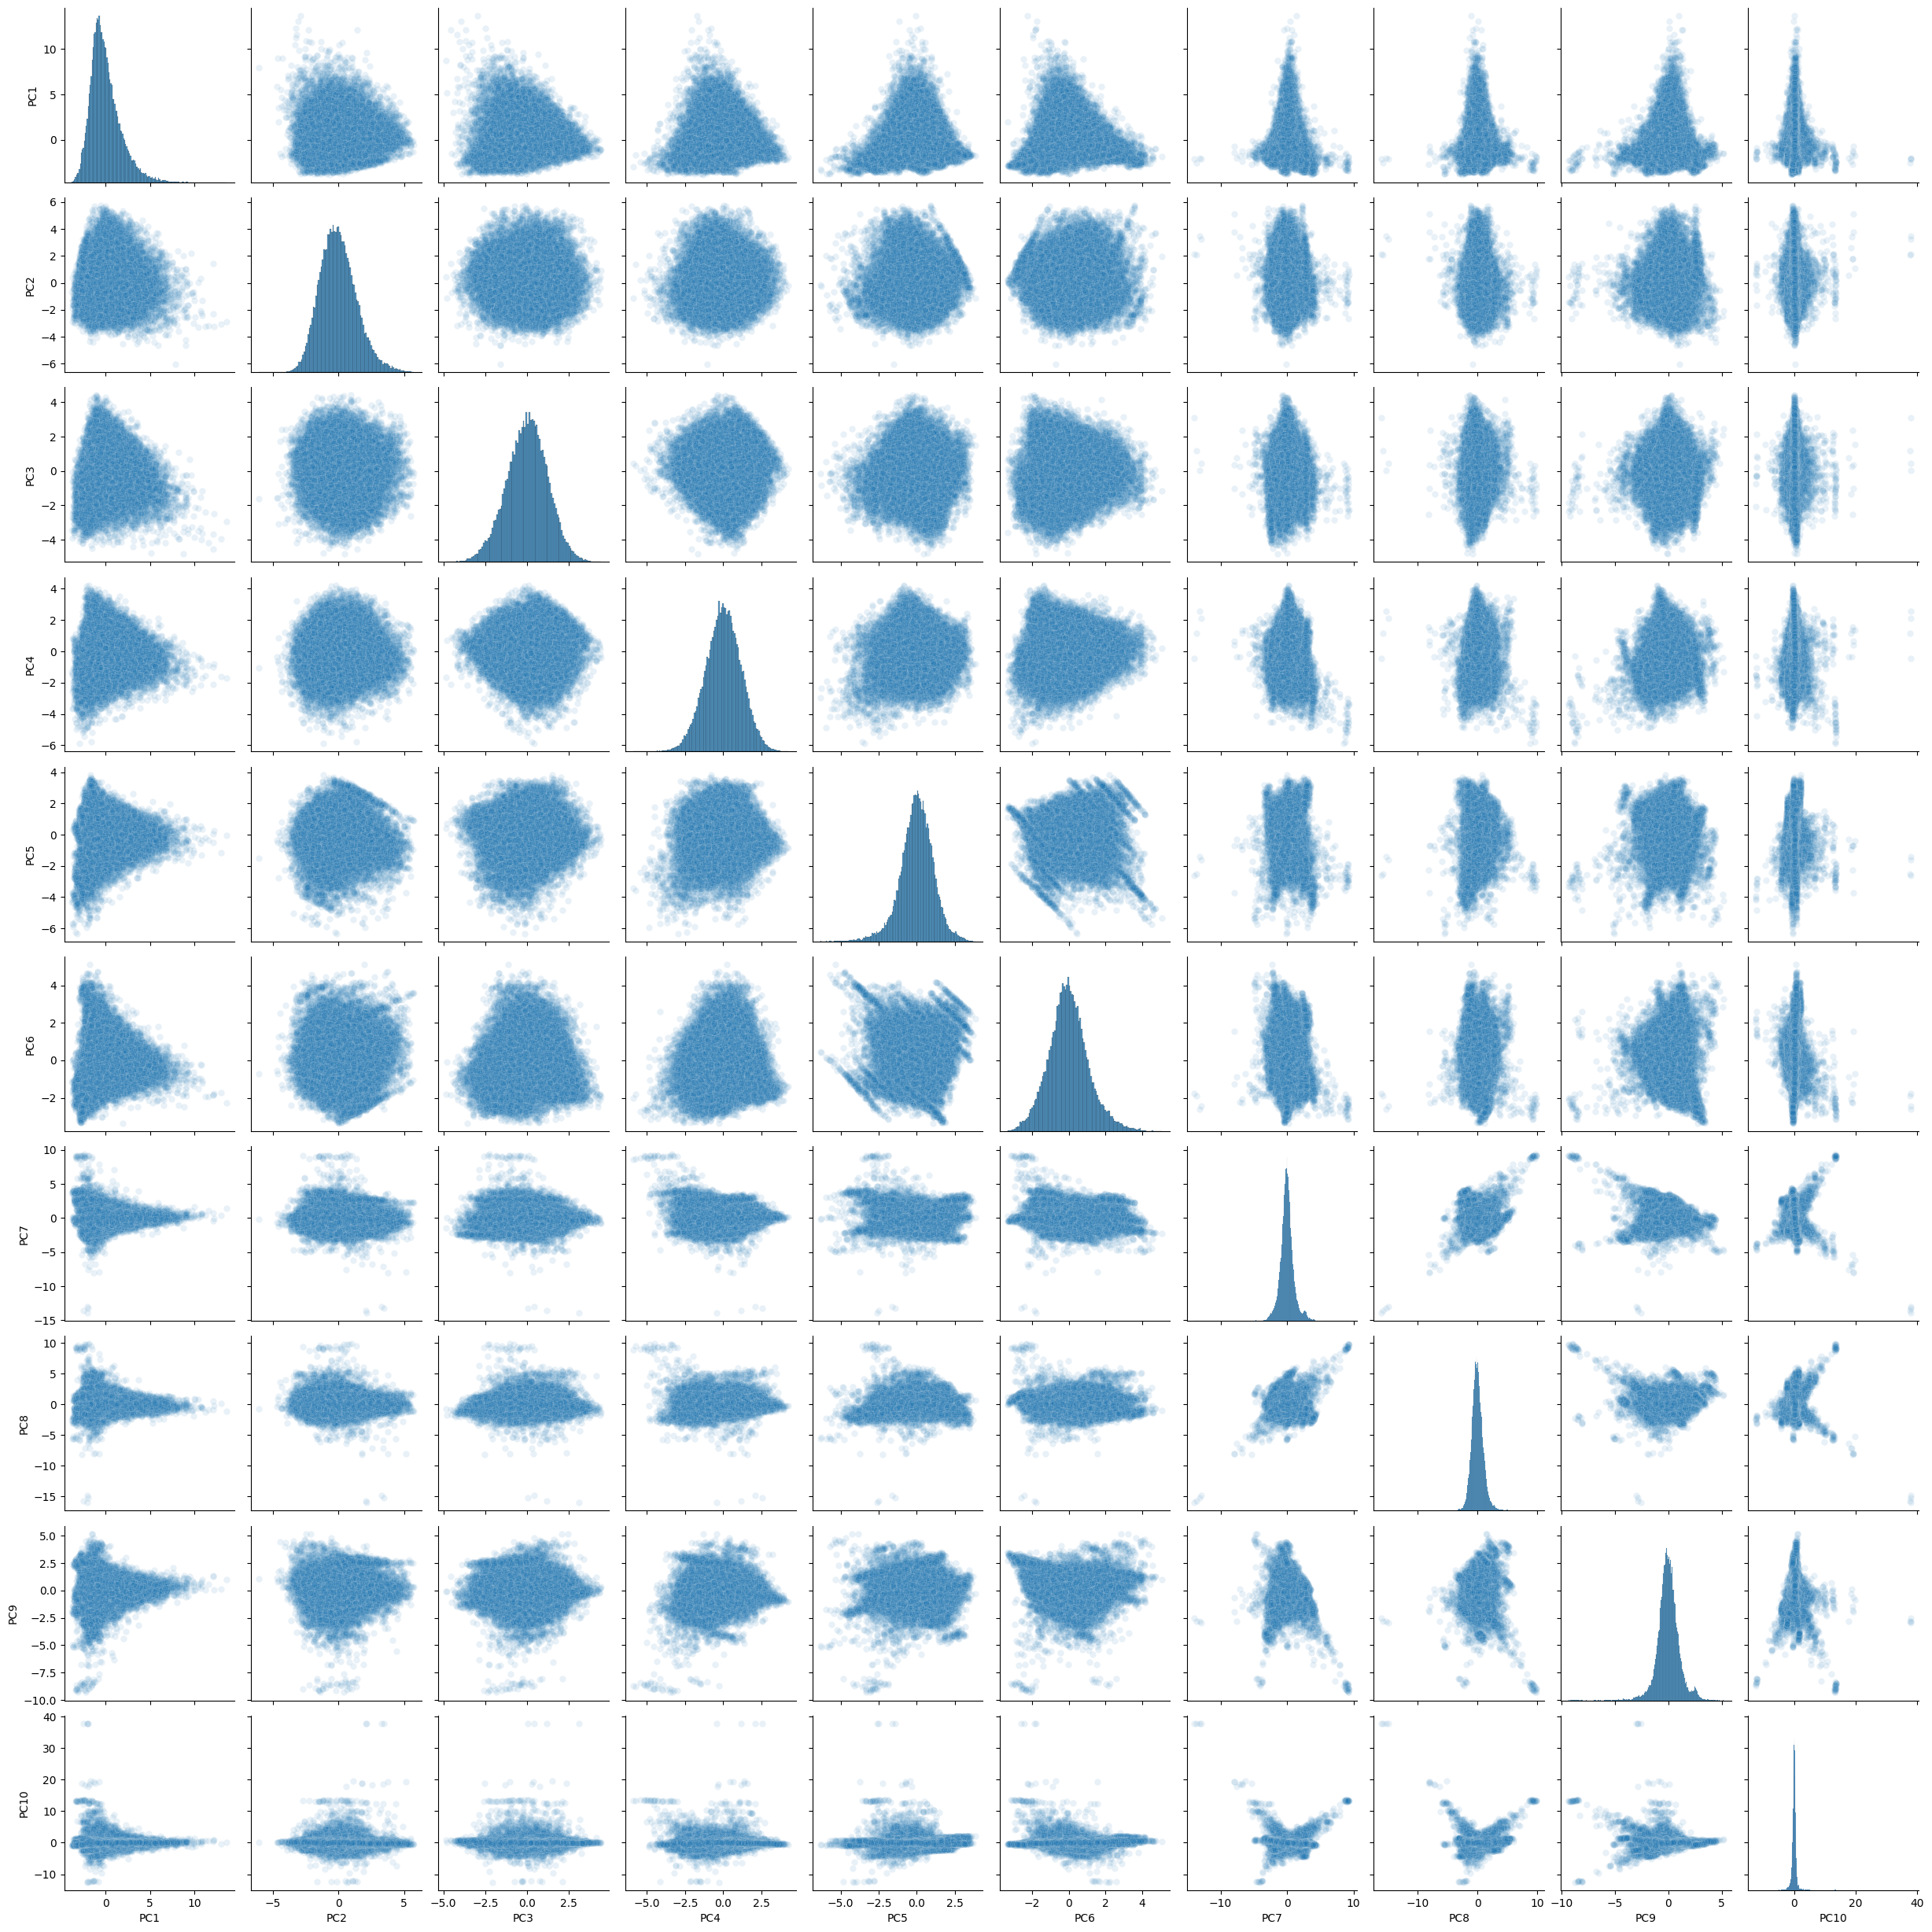

In [4]:
pca = PCA(n_components=31)
X_reduced_pca = pca.fit_transform(X_sample)

X_reduced_pca_df = pd.DataFrame(X_reduced_pca[:,:10])
X_reduced_pca_df.columns = [f"PC{col+1}" for col in X_reduced_pca_df.columns.tolist()]

sns.pairplot(X_reduced_pca_df, plot_kws={'alpha':0.1})

### Explained variance ratio



2025-11-26 09:01:51,579 - INFO - category.update:223 - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.

2025-11-26 09:01:51,582 - INFO - category.update:223 - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.



<Axes: xlabel='principle_component', ylabel='explained_variance_ratio'>

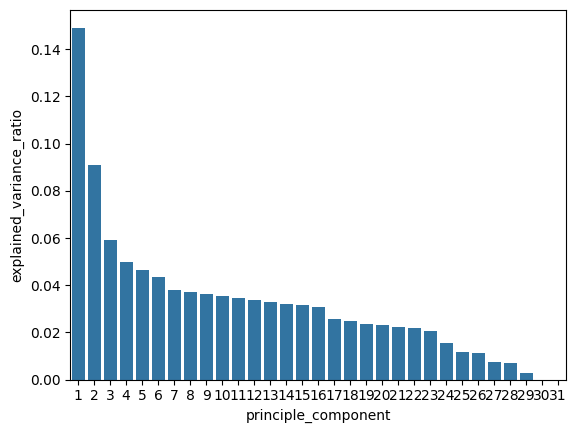

In [9]:

df_explained_variance_ratio = pd.DataFrame({'explained_variance_ratio': pca.explained_variance_ratio_,
              'principle_component': pd.Categorical([i+1 for i in range(len(pca.explained_variance_ratio_))])})

sns.barplot(data=df_explained_variance_ratio, y='explained_variance_ratio', x='principle_component')

## t-SNE


100%|██████████| 7/7 [00:23<00:00,  3.30s/it]


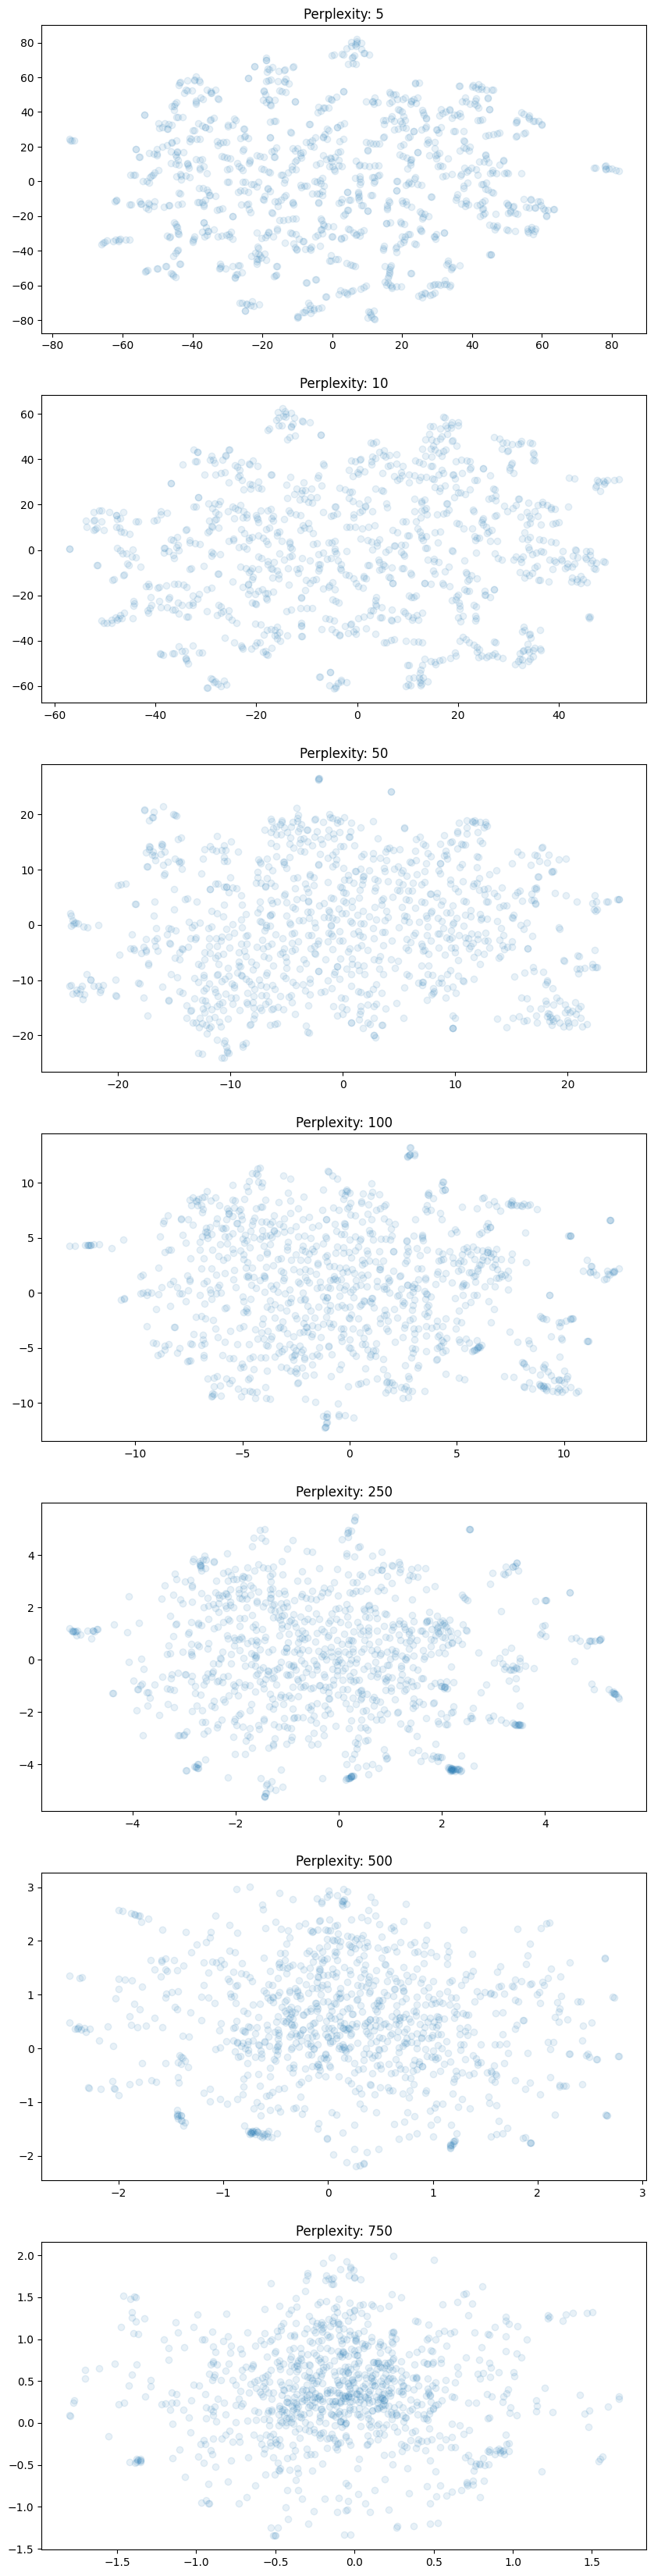

In [11]:
perplexities = [5, 10, 50, 100, 250, 500, 750]
fig, axs = plt.subplots(nrows=len(perplexities),figsize=(10, len(perplexities)*6))

for i, perplexity in enumerate(tqdm(perplexities)):
    tsne = TSNE(n_components = 2, perplexity=perplexity, n_jobs=-1)
    X_reduced_tsne = tsne.fit_transform(X_sample)

    axs[i].scatter(X_reduced_tsne[:,0], X_reduced_tsne[:,1], alpha=0.1)
    axs[i].set_title(f"Perplexity: {perplexity}")

## UMAP

  0%|          | 0/5 [00:00<?, ?it/s]/Users/krusand/Documents/GitHub/02807-CT-Project/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/krusand/Documents/GitHub/02807-CT-Project/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/krusand/Documents/GitHub/02807-CT-Project/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/krusand/Documents/GitHub/02807-CT-Project/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
 20%|██        | 1/5 [00:03<00:15,  3.84s/it]/Users/krusand/Documents/GitHub/02807-CT-Project/.venv/lib/python3.10/site-pac

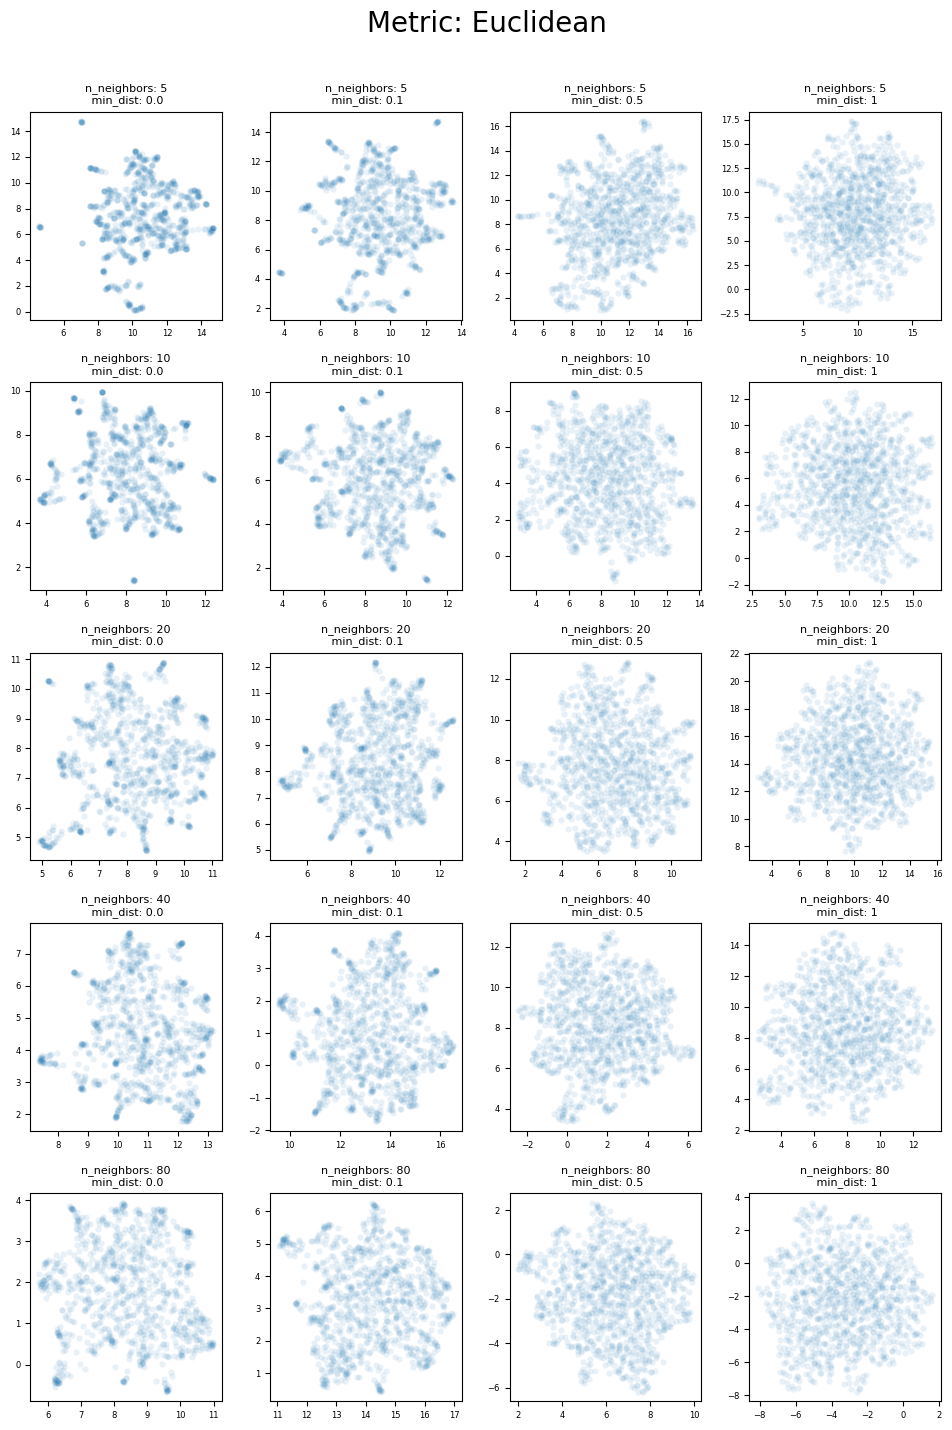

In [15]:
params = {
        "n_neighbors" : [5, 10, 20, 40, 80],
        "min_dist" : [0.0, 0.1, 0.5, 1],
        "metric" : ["euclidean", "manhattan"]
}

fig, axs = plt.subplots(nrows=len(params["n_neighbors"]), ncols=len(params["min_dist"]), figsize=(10,15))

for i in tqdm(range(len(params["n_neighbors"]))):
    for j in range(len(params["min_dist"])):
        n_neighbors = params["n_neighbors"][i]
        min_dist = params["min_dist"][j]
        metric = params["metric"][0]
        
        umap_model = UMAP(
            n_neighbors=n_neighbors,         # smaller = more local focus, higher = more global
            min_dist=min_dist,           # smaller = tighter clusters, higher = more spread
            n_components=2, 
            metric=metric,   
            random_state=42
        )
        
        X_reduced_umap = umap_model.fit_transform(X_sample)

        sns.scatterplot(x=X_reduced_umap[:, 0], y=X_reduced_umap[:, 1], s=20, alpha=0.1, ax=axs[i][j], legend=False)
        
        # Layout
        axs[i][j].set_title(f"n_neighbors: {n_neighbors}\n min_dist: {min_dist}", fontsize=8) # Set title
        axs[i][j].tick_params(axis='both', labelsize=6) # Reduce tick label font size

fig.suptitle(f"Metric: {metric.title()}", fontsize = 20)

plt.subplots_adjust(hspace=1.2)  # Increase vertical space
plt.tight_layout(rect=[0, 0.03, 0.97, 0.97])  # Leaves space for suptitle



## Clustering

Text(0.5, 1.0, 'Metric: euclidean, Linkage: ward')

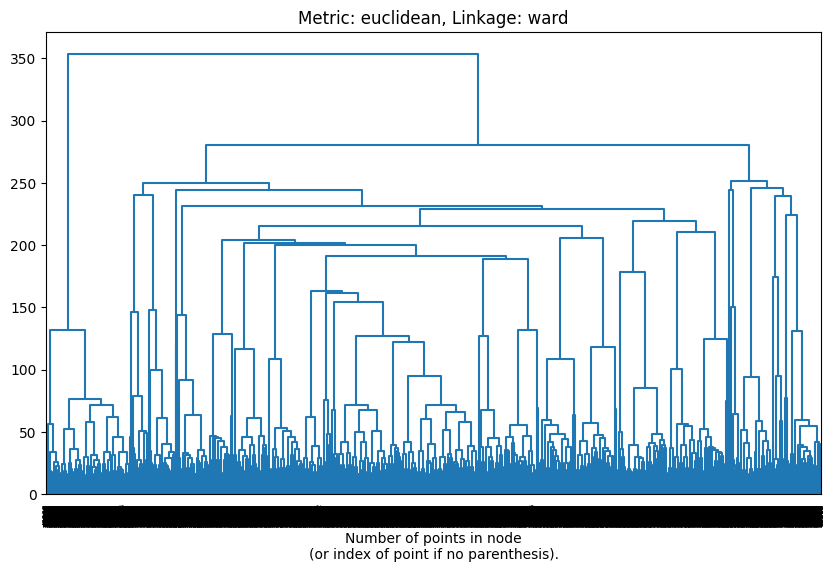

In [5]:

def plot_dendrogram(model, **kwargs):
    "Taken from the sklearn documentation"
    # Create linkage matrix and then plot the dendrogram

    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    # Plot the corresponding dendrogram
    dendrogram(linkage_matrix, **kwargs)


# Plot euclidean + ward

metric = 'euclidean'
linkage = 'ward'
fig, ax = plt.subplots(ncols=1, figsize=(10,6))

model = AgglomerativeClustering(distance_threshold=0, n_clusters=None,  linkage=linkage, metric=metric)

model = model.fit(X_sample)
# plot the top three levels of the dendrogram
plot_dendrogram(model, truncate_mode = 'level', p=100, color_threshold=0,ax= ax)

ax.set_xlabel("Number of points in node\n(or index of point if no parenthesis).")
ax.set_title(f"Metric: {metric}, Linkage: {linkage}")


In [7]:
agg_clust = AgglomerativeClustering(n_clusters=3,  linkage=linkage, metric=metric)

agg_clust.fit_predict(X_sample)



: 

: 

In [8]:
X_dbscan_example = X_scaled.sample(100)


In [ ]:
from sklearn.base import BaseEstimator, ClusterMixin

class DBSCAN_own(ClusterMixin, BaseEstimator):
    def __init__(self, eps=1, m=1):
        self.eps = eps
        self.m = m
    
    def fit(self, X):
        def p_is_core(p):
            
            return False
        
        visited = [False] * X.shape[0]
        for i, p in enumerate(X):
            if visited[i] == False:
                core_point_bool = p_is_core(p)
                if not core_point_bool:
                    continue
                elif core_point_bool:
                    continue


In [ ]:
dbscan = DBSCAN()
dbscan.fit_predict()


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

# Features based on rating matrix


In [22]:
ratings_long = pd.read_parquet(DATA_PREPROCESSED_DIR / "ratings_w_freq-0.33_w_rec-0.33_w_tfidf-0.33.pq")

def convert_to_user_term_matrix(ratings):
    """Converts from long to wide in CSR format. Input must have column names ['user', 'item', 'rating']"""
    users = ratings["user"].unique()
    item = ratings["item"].unique()
    shape = (len(users), len(item))

    # Create indices for users and movies
    user_cat = CategoricalDtype(categories=sorted(users), ordered=True)
    product_cat = CategoricalDtype(categories=sorted(item), ordered=True)
    user_index = ratings["user"].astype(user_cat).cat.codes
    product_index = ratings["item"].astype(product_cat).cat.codes

    # Conversion via COO matrix
    coo = sparse.coo_matrix((ratings_long["rating"], (user_index, product_index)), shape=shape)
    ratings_matrix = coo.tocsr()
    return ratings_matrix

ratings_matrix = convert_to_user_term_matrix(ratings_long)

In [24]:
tfidf = pd.read_parquet(DATA_PREPROCESSED_DIR / "user_product_tfidf_min_max_scaled.pq").drop("tfidf_score", axis=1)
tfidf.columns = ["user", "item", "rating"]

tfidf_matrix = convert_to_user_term_matrix(tfidf)

In [ ]:
svd = TruncatedSVD(n_components=75)
X_svd = svd.fit_transform(tfidf_matrix)

umap = UMAP(n_neighbors=10, min_dist=0.5, verbose=True)
X_umap_svd = umap.fit_transform(X_svd)


In [ ]:

plt.scatter(X_umap_svd[:,0], X_umap_svd[:,1])